In [1]:
import pandas as pd
import datetime as dtm
from chinese_calendar import is_holiday
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import distributions
import powerlaw
import numpy as np
import seaborn as sns
from h3 import h3
from MoranI import moranI
from scipy.stats import kstest, gaussian_kde
import matplotlib.ticker as ticker

In [2]:
res = 9
work_path = os.path.abspath(os.getcwd()+os.path.sep+"..")
data_path = os.path.join(work_path,'Results','Suzhou','RES=%s' % res)

all_strength = pd.read_csv(os.path.join(data_path,'all_strength.csv'))
all_strength['date'] = all_strength['date'].apply(lambda x: dtm.datetime.strptime(str(x),"%Y%m%d"))
all_strength['Holiday'] =  all_strength.date.apply(lambda x: is_holiday(x))

In [7]:
sele_strength = all_strength.loc[(all_strength['date'].dt.month>=10)]
day_fit = []
for dd in sele_strength['date'].value_counts().to_frame().index:
    day_strength = sele_strength.loc[sele_strength['date']==dd]
    s = day_strength['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
    xdata = s['index'].values
    ydata = s['strength_values'].values
    ydata = ydata/sum(ydata)
    def func(x,alpha,a):
        pl = np.power(x,-alpha)
        return pl*a
    def func2(x,alpha,beta,a):
        pl = np.power(x,-alpha)
        ex = np.exp(-x/beta)
        return pl*ex*a
    popt_l, pcov_l = curve_fit(func, xdata, ydata, p0=[0.1,0.01], maxfev = 5108000)
    popt_t, pcov_t = curve_fit(func2, xdata, ydata, p0=[0.1,5,0.01], maxfev = 5108000)
    ks_l = kstest(np.cumsum(ydata),np.cumsum(func(xdata, *popt_l)))
    ks_t = kstest(np.cumsum(ydata),np.cumsum(func2(xdata, *popt_t)))
    day_fit.append([dd,popt_l[0],ks_l[0],ks_l[1],popt_t[0],popt_t[1],ks_t[0],ks_t[1]])

pd.DataFrame(day_fit).to_csv(os.path.join(data_path,'SZfit.csv'))

In [8]:
pd.DataFrame(day_fit)

,0,1,2,3,4,5,6,7
0,2021-10-22,0.568495,0.486248,1.825493e-109,0.184995,55.233279,0.831041,0.000000e+00
1,2021-10-18,0.571131,0.482072,4.839870e-106,0.202187,58.299123,0.820717,0.000000e+00
2,2021-10-12,0.572936,0.483450,6.213105e-106,0.213205,59.019742,0.816449,0.000000e+00
3,2021-10-19,0.568165,0.478564,2.445961e-104,0.185546,55.936318,0.822532,0.000000e+00
4,2021-10-29,0.565755,0.479230,5.617125e-103,0.177823,53.352574,0.830800,0.000000e+00
5,2021-10-14,0.572481,0.489164,1.603191e-105,0.163818,47.574932,0.841073,0.000000e+00
6,2021-10-26,0.563763,0.476768,3.457929e-102,0.170413,54.230970,0.826263,0.000000e+00
7,2021-10-27,0.572073,0.480276,2.892746e-106,0.185732,54.028897,0.831361,0.000000e+00
8,2021-10-25,0.563768,0.477046,1.510291e-103,0.160209,52.866926,0.828343,0.000000e+00
9,2021-10-15,0.578558,0.503086,3.070165e-112,0.151956,43.638421,0.852881,0.000000e+00


In [ ]:
d = 1
for day in all_strength.date.unique():
    daily = all_strength[all_strength['date']==day]
    s = daily['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
    xdata = s['index'].values
    ydata = s['strength_values'].values
    ydata = ydata
    ydata = ydata/sum(ydata)

    plt.clf()

    plt.rcParams['font.sans-serif'] = ['Verdana']
    plt.rcParams['savefig.dpi'] = 600
    plt.rcParams['figure.figsize'] = (5.0, 4.5)
    plt.scatter(xdata, ydata, s= 5, color='#0f95b0', label='Data')
    plt.xlabel('Node Strength ($k$)',fontsize=12)
    plt.ylabel('P$(k)$',fontsize=12)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylim((10e-5,10e-2))
#    plt.title('Lianyungang',loc='left')
#    plt.show()
    if d<10:
        figname = 'SZP0'+str(d)+'.png'
    if d>=10:
        figname = 'SZP'+str(d)+'.png'
    plt.savefig(os.path.join(data_path,figname))
    d = d + 1

In [17]:
daily = all_strength[all_strength['date']=='2021-10-20']
s = daily['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
xdata = s['index'].values
ydata = s['strength_values'].values
ydata = ydata/sum(ydata)
def func(x,alpha,a):
    pl = np.power(x,-alpha)
    return pl*a
def func2(x,alpha,beta,a):
    pl = np.power(x,-alpha)
    ex = np.exp(-x/beta)
    return pl*ex*a
popt_l, pcov_l = curve_fit(func, xdata, ydata, p0=[0.1,0.01], maxfev = 5108000)
popt_t, pcov_t = curve_fit(func2, xdata, ydata, p0=[0.1,5,0.01], maxfev = 5108000)
print(popt_l)
print(popt_t)

[0.58580855 0.03504079]
[1.94035669e-01 4.70285914e+01 2.62303115e-02]


In [4]:

from sklearn.metrics import r2_score
 
# y_true为实际观测值，y_pred为模型预测值
r2_l = r2_score(ydata, func(xdata, *popt_l))
r2_t = r2_score(ydata, func2(xdata, *popt_t))
print("ppl r2: ", r2_l)
print("etpl r2: ", r2_t)

ppl r2:  0.6269013229367241
etpl r2:  0.7259428417714084


In [5]:
print(r2_score(np.cumsum(ydata),np.cumsum(func(xdata, *popt_l))))
print(r2_score(np.cumsum(ydata),np.cumsum(func2(xdata, *popt_t))))

0.07230850123935506
-0.46490576248736737


In [6]:
# grouped = s.groupby((s.index // 2))['strength_values'].agg('sum').to_frame()
# grouped.index = grouped.index + 0.5
# s = grouped.reset_index(drop=False).sort_values('index')

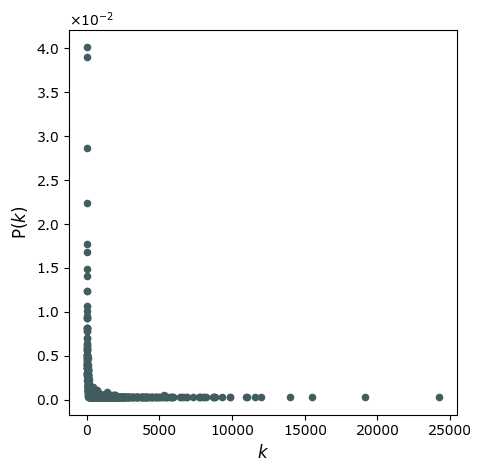

In [5]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (5.0, 5)
plt.scatter(xdata, ydata, s= 20, color='#425d5f', label='Data')
plt.xlabel('$k$',fontsize=12)
plt.ylabel('P$(k)$',fontsize=12)
ax = plt.gca()
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2,-2))
ax.yaxis.set_major_formatter(formatter)
#plt.title('Beijing',loc='left')
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\SZ1.tif")

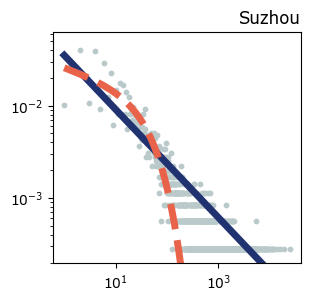

In [6]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (3.2,3)
plt.scatter(xdata, ydata, s= 10, color='#bacacb', alpha=1)
plt.plot(xdata, func(xdata, *popt_l), '#213271', lw=5, label=r'$Ck^{-\alpha}$')
plt.plot(xdata, func2(xdata, *popt_t),'#e86349', lw=5, linestyle = "--", label=r'$Ck^{-\alpha}e^{-\frac{k}{\lambda}}$')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10**-3.7,10**-1.2))
#plt.legend(loc='upper right',frameon =True,fontsize = 10)
# plt.title('Bus-Suzhou',loc='right')
plt.title('Suzhou',loc='right')
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\SZ2.tif")

In [5]:
from scipy.stats import kstest

print(popt_l)
print(popt_t)
print(kstest(np.cumsum(ydata),np.cumsum(func(xdata, *popt_l))))
print(kstest(np.cumsum(ydata),np.cumsum(func2(xdata, *popt_t))))

[0.58580855 0.03504079]
[1.94035669e-01 4.70285914e+01 2.62303115e-02]
KstestResult(statistic=0.5005336179295624, pvalue=4.583543740798274e-107, statistic_location=0.999999999999993, statistic_sign=1)
KstestResult(statistic=0.8441835645677694, pvalue=0.0, statistic_location=0.6561739922716989, statistic_sign=-1)


In [18]:
c1 = len(np.where(np.cumsum(ydata)<0.50)[0])
c2 = len(np.where(np.cumsum(ydata)<0.55)[0])
c3 = len(np.where(np.cumsum(ydata)<0.60)[0])
c4 = len(np.where(np.cumsum(ydata)<0.65)[0])
c5 = len(np.where(np.cumsum(ydata)<0.70)[0])
c6 = len(np.where(np.cumsum(ydata)<0.75)[0])
c7 = len(np.where(np.cumsum(ydata)<0.80)[0])
c8 = len(np.where(np.cumsum(ydata)<0.85)[0])
c9 = len(np.where(np.cumsum(ydata)<0.90)[0])
c0 = len(np.where(np.cumsum(ydata)<0.95)[0])
vline = [c1,c2,c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]
print(c1,c2,c3,c4,c5,c6,c7,c8,c9,c0,len(ydata))

61 81 106 141 194 267 365 475 607 763 937


In [19]:
def color_vector(start_color, end_color, num_steps):
    # 计算每一阶的颜色
    colors = []
    for i in range(num_steps):
        r = int(start_color[0] - (start_color[0] - end_color[0]) / (num_steps - 1) * i)
        g = int(start_color[1] - (start_color[1] - end_color[1]) / (num_steps - 1) * i)
        b = int(start_color[2] - (start_color[2] - end_color[2]) / (num_steps - 1) * i)
        color = (r, g, b)
        colors.append(color)
    
    # 输出每一阶颜色的 16 进制表示
    hex_colors = []
    for color in colors:
        hex_color = "#{:02x}{:02x}{:02x}".format(color[0], color[1], color[2])
        hex_colors.append(hex_color)
    
    # 返回颜色向量
    return hex_colors

In [12]:
# def puring_fit(strength,c):
#     strength = strength.sort_values(by='index', ascending=True).reset_index(drop=True)
#     strength = strength.iloc[:c]
    
#     ydata = strength['strength_values'].values
#     xdata = strength['index'].values
#     ydata = ydata/sum(ydata)

#     return xdata, ydata

def puring_fit(strength,c):
    strength = strength.sort_values(by='index', ascending=True).reset_index(drop=True)
    
    ydata = strength['strength_values'].values
    xdata = strength['index'].values
    ydata = ydata/sum(ydata)

    xdata = xdata[:c]
    ydata = ydata[:c]


    return xdata, ydata

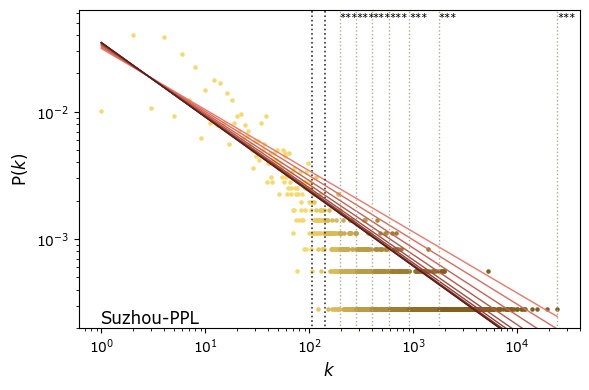

In [20]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

xinpos = 10**-1.3

vline = [c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]

lyg_dot_clr = color_vector((248,216,106), (131,94,29), len(vline))
lyg_lne_clr = color_vector((241,118,102), (92,30,25), len(vline))

ppl = pd.DataFrame([])

for posi in range(len(vline)):
    c = vline[posi]
    x_data, y_data = puring_fit(s,c)
    popt, pcov = curve_fit(func, x_data, y_data, p0=[.1,.01], maxfev = 5108000)
    y_fit = func(xdata, *popt)
    ks = kstest(np.cumsum(y_data[:c]),np.cumsum(y_fit[:c]))

    pl = pd.DataFrame({
        'puring': [posi],
        'et_alpha': [popt[0]],
        'et_d': [ks[0]],
        'et_pvalue': [ks[1]]
    })

    ppl = pd.concat([ppl,pl])

    #虚线
    if ks[1] < 0.05:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-1, lw=1, ls=":",color="#b5aa90")
        if ks[1] < 0.001:
            plt.text(x_data.max(),xinpos,"***", ha='left', va='bottom',fontsize=7)
        elif (ks[1] >= 0.001)&(ks[1] < 0.01):
            plt.text(x_data.max(),xinpos,"**", ha='left', va='bottom',fontsize=7)
        else:
            plt.text(x_data.max(),xinpos,"*", ha='left', va='bottom',fontsize=7)
    else:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-2, lw=1.2, ls=":",color="#393733")

    #点
    if posi == 0:
        plt.scatter(xdata[:c], ydata[:c], s= 5, color=lyg_dot_clr[posi])
    else:
        plt.scatter(xdata[vline[posi-1]:vline[posi]], ydata[vline[posi-1]:vline[posi]], s= 5, color=lyg_dot_clr[posi])

    #线
    plt.plot(xdata, y_fit, lw=1, color=lyg_lne_clr[posi])


plt.text(xdata.min(),10**-3.7,"Suzhou-PPL", ha='left', va='bottom', fontsize=12)

# plt.title('Bus-Suzhou',loc='right')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10**-3.7,10**-1.2))
plt.xlabel('$k$',fontsize=12)
plt.ylabel('P$(k)$',fontsize=12)
# plt.legend(loc='upper right')
plt.tight_layout()
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\SZppl.tif")

In [21]:
ppl

,puring,et_alpha,et_d,et_pvalue
0,0,0.480523,0.113208,5.073654e-01
0,1,0.505245,0.156028,6.448796e-02
0,2,0.530001,0.206186,5.044480e-04
0,3,0.550465,0.265918,1.042109e-08
0,4,0.566424,0.326027,1.458844e-17
0,5,0.575888,0.374737,4.424052e-30
0,6,0.582163,0.418451,5.391269e-48
0,7,0.585465,0.462647,4.478444e-74
0,8,0.585809,0.500534,4.583544e-107


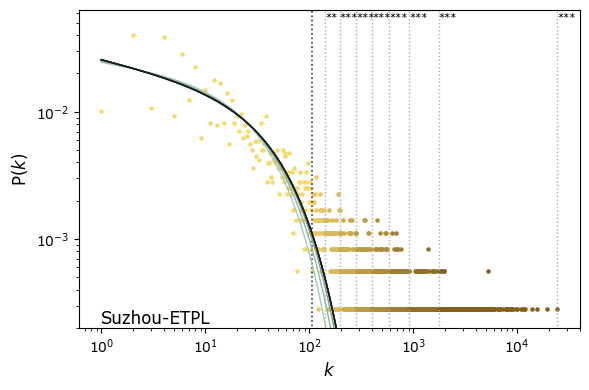

In [22]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

vline = [c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]

lyg_dot_clr = color_vector((248,216,106), (131,94,29), len(vline))
lyg_lne_clr = color_vector((164,202,182), (20,30,27), len(vline))

etpl = pd.DataFrame([])

for posi in range(len(vline)):
    c = vline[posi]
    x_data, y_data = puring_fit(s,c)
    poptt, pcovv = curve_fit(func2, x_data, y_data, p0=[0.1,5,0.01], maxfev = 5108000)
    y_fit = func2(xdata, *poptt)
    ks = kstest(np.cumsum(y_data[:c]),np.cumsum(y_fit[:c]))

    et = pd.DataFrame({
        'puring': [posi],
        'et_alpha': [poptt[0]],
        'et_lambda': [poptt[1]],
        'et_d': [ks[0]],
        'et_pvalue': [ks[1]]
    })

    etpl = pd.concat([etpl,et])

    #虚线
    if ks[1] < 0.05:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-1, lw=1, ls=":",color="#b5aa90")
        if ks[1] < 0.001:
            plt.text(x_data.max(),xinpos,"***", ha='left', va='bottom',fontsize=7)
        elif (ks[1] >= 0.001)&(ks[1] < 0.01):
            plt.text(x_data.max(),xinpos,"**", ha='left', va='bottom',fontsize=7)
        else:
            plt.text(x_data.max(),xinpos,"*", ha='left', va='bottom',fontsize=7)
    else:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-2, lw=1.2, ls=":",color="#393733")

    #点
    if posi == 0:
        plt.scatter(xdata[:vline[posi]], ydata[:vline[posi]], s= 5, color=lyg_dot_clr[posi])
    else:
        plt.scatter(xdata[vline[posi-1]:vline[posi]], ydata[vline[posi-1]:vline[posi]], s= 5, color=lyg_dot_clr[posi])

    #线
    plt.plot(xdata, y_fit, lw=1, color=lyg_lne_clr[posi])

plt.text(xdata.min(),10**-3.7,"Suzhou-ETPL", ha='left', va='bottom', fontsize=12)

# plt.title('Bus-Suzhou',loc='right')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10**-3.7,10**-1.2))
plt.xlabel('$k$',fontsize=12)
plt.ylabel('P$(k)$',fontsize=12)
# plt.legend(loc='upper right')
plt.tight_layout()
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\SZetpl.tif")


In [23]:
etpl

,puring,et_alpha,et_lambda,et_d,et_pvalue
0,0,0.120087,34.045569,0.122642,4.042395e-01
0,1,0.153982,39.306611,0.205674,5.028605e-03
0,2,0.178376,43.799173,0.324742,1.891927e-09
0,3,0.190852,46.352542,0.460674,6.171243e-26
0,4,0.193820,46.982959,0.600000,1.954339e-61
0,5,0.194032,47.027828,0.692632,3.022231e-109
0,6,0.194036,47.028589,0.759473,5.875573e-172
0,7,0.194036,47.028591,0.808650,1.718099e-250
0,8,0.194036,47.028591,0.844184,0.000000e+00


### 不要了

In [1]:
popt1, pcov1 = curve_fit(func, xdata[:c1], ydata[:c1], p0=[0.1,0.01], maxfev = 5108000)
popt2, pcov2 = curve_fit(func, xdata[:c2], ydata[:c2], p0=[0.1,0.01], maxfev = 5180000)
popt3, pcov3 = curve_fit(func, xdata[:c3], ydata[:c3], p0=[0.1,0.01], maxfev = 5108000)
popt4, pcov4 = curve_fit(func, xdata[:c4], ydata[:c4], p0=[0.1,0.01], maxfev = 5108000)
popt5, pcov5 = curve_fit(func, xdata[:c5], ydata[:c5], p0=[0.1,0.01], maxfev = 5108000)
popt6, pcov6 = curve_fit(func, xdata[:c5], ydata[:c5], p0=[0.1,0.01], maxfev = 5108000)
popt6, pcov6 = curve_fit(func, xdata[:c6], ydata[:c6], p0=[0.1,0.01], maxfev = 5108000)
popt7, pcov7 = curve_fit(func, xdata[:c7], ydata[:c7], p0=[0.1,0.01], maxfev = 5108000)
popt8, pcov8 = curve_fit(func, xdata[:c8], ydata[:c8], p0=[0.1,0.01], maxfev = 5108000)
popt9, pcov9 = curve_fit(func, xdata[:c9], ydata[:c9], p0=[0.1,0.01], maxfev = 5108000)
popt0, pcov0 = curve_fit(func, xdata[:c0], ydata[:c0], p0=[0.1,0.01], maxfev = 5108000)
np.vstack((popt_l,popt0,popt9,popt8,popt7,popt6,popt5,popt4,popt3))

NameError: name 'curve_fit' is not defined

In [12]:

popt11, pcov11 = curve_fit(func2, xdata[:c1], ydata[:c1], p0=[0.1,50,0.01], maxfev = 5108000)
popt22, pcov22 = curve_fit(func2, xdata[:c2], ydata[:c2], p0=[0.1,50,0.01], maxfev = 5180000)
popt33, pcov33 = curve_fit(func2, xdata[:c3], ydata[:c3], p0=[0.1,50,0.01], maxfev = 5108000)
popt44, pcov44 = curve_fit(func2, xdata[:c4], ydata[:c4], p0=[0.1,50,0.01], maxfev = 5108000)
popt55, pcov55 = curve_fit(func2, xdata[:c5], ydata[:c5], p0=[0.1,50,0.01], maxfev = 5108000)
popt66, pcov66 = curve_fit(func2, xdata[:c6], ydata[:c6], p0=[0.1,50,0.01], maxfev = 5108000)
popt77, pcov77 = curve_fit(func2, xdata[:c7], ydata[:c7], p0=[0.1,50,0.01], maxfev = 5108000)
popt88, pcov88 = curve_fit(func2, xdata[:c8], ydata[:c8], p0=[0.1,50,0.01], maxfev = 5108000)
popt99, pcov99 = curve_fit(func2, xdata[:c9], ydata[:c9], p0=[0.1,50,0.01], maxfev = 5108000)
popt00, pcov00 = curve_fit(func2, xdata[:c0], ydata[:c0], p0=[0.1,50,0.01], maxfev = 5108000)
np.vstack((popt_t,popt00,popt99,popt88,popt77,popt66,popt55,popt44,popt33))

array([[1.94035669e-01, 4.70285914e+01, 2.62303115e-02],
       [1.94024972e-01, 4.70260783e+01, 2.62301890e-02],
       [1.94024974e-01, 4.70260779e+01, 2.62301892e-02],
       [1.94021333e-01, 4.70253101e+01, 2.62301299e-02],
       [1.93809268e-01, 4.69803802e+01, 2.62266976e-02],
       [1.90859534e-01, 4.63543911e+01, 2.61800424e-02],
       [1.78384581e-01, 4.38010976e+01, 2.59906433e-02],
       [1.53979234e-01, 3.93058578e+01, 2.56434581e-02],
       [1.20076732e-01, 3.40439757e+01, 2.52029140e-02]])

In [13]:
def color_vector(start_color, end_color, num_steps):
    # 计算每一阶的颜色
    colors = []
    for i in range(num_steps):
        r = int(start_color[0] - (start_color[0] - end_color[0]) / (num_steps - 1) * i)
        g = int(start_color[1] - (start_color[1] - end_color[1]) / (num_steps - 1) * i)
        b = int(start_color[2] - (start_color[2] - end_color[2]) / (num_steps - 1) * i)
        color = (r, g, b)
        colors.append(color)
    
    # 输出每一阶颜色的 16 进制表示
    hex_colors = []
    for color in colors:
        hex_color = "#{:02x}{:02x}{:02x}".format(color[0], color[1], color[2])
        hex_colors.append(hex_color)
    
    # 返回颜色向量
    return hex_colors

In [14]:
print(kstest(ydata[:c3],func(xdata[:c3], *popt3)))
print(kstest(ydata[:c4],func(xdata[:c4], *popt4)))
print(kstest(ydata[:c5],func(xdata[:c5], *popt5)))
print(kstest(ydata[:c6],func(xdata[:c6], *popt6)))
print(kstest(ydata[:c7],func(xdata[:c7], *popt7)))
print(kstest(ydata[:c8],func(xdata[:c8], *popt8)))
print(kstest(ydata[:c9],func(xdata[:c9], *popt9)))
print(kstest(ydata[:c0],func(xdata[:c0], *popt0)))
print(kstest(ydata,func(xdata, *popt_l)))

KstestResult(statistic=0.4528301886792453, pvalue=3.618379945230707e-10, statistic_location=0.003367003367003367, statistic_sign=1)
KstestResult(statistic=0.48226950354609927, pvalue=3.1989403150715073e-15, statistic_location=0.0025252525252525255, statistic_sign=1)
KstestResult(statistic=0.5257731958762887, pvalue=7.368753628606557e-25, statistic_location=0.001964085297418631, statistic_sign=1)
KstestResult(statistic=0.5880149812734082, pvalue=3.923861958560616e-43, statistic_location=0.0014029180695847362, statistic_sign=1)
KstestResult(statistic=0.6301369863013698, pvalue=2.8307700417075855e-68, statistic_location=0.001122334455667789, statistic_sign=1)
KstestResult(statistic=0.6147368421052631, pvalue=3.9476931237926486e-84, statistic_location=0.0008417508417508417, statistic_sign=1)
KstestResult(statistic=0.5848434925864909, pvalue=1.642798425287887e-96, statistic_location=0.0005611672278338945, statistic_sign=1)
KstestResult(statistic=0.5425950196592398, pvalue=2.2865892086073637

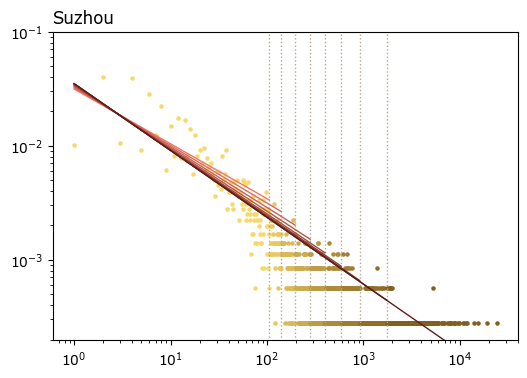

In [16]:

plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

lyg_dot_clr = color_vector((248,216,106), (131,94,29), 9)
lyg_lne_clr = color_vector((241,118,102), (92,30,25), 9)

for v in range(2,10):
    plt.vlines(x=xdata[vline[v]-1], ymin=10e-5,ymax=10e-2, lw=1, ls=":",color="#b5aa90")

#plt.scatter(xdata[:c1], ydata[:c1], s= 5, color=lyg_dot_clr[0])
#plt.scatter(xdata[c1:c2], ydata[c1:c2], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[:c3], ydata[:c3], s= 5, color=lyg_dot_clr[0])
plt.scatter(xdata[c3:c4], ydata[c3:c4], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[c4:c5], ydata[c4:c5], s= 5, color=lyg_dot_clr[2])
plt.scatter(xdata[c5:c6], ydata[c5:c6], s= 5, color=lyg_dot_clr[3])
plt.scatter(xdata[c6:c7], ydata[c6:c7], s= 5, color=lyg_dot_clr[4])
plt.scatter(xdata[c7:c8], ydata[c7:c8], s= 5, color=lyg_dot_clr[5])
plt.scatter(xdata[c8:c9], ydata[c8:c9], s= 5, color=lyg_dot_clr[6])
plt.scatter(xdata[c9:c0], ydata[c9:c0], s= 5, color=lyg_dot_clr[7])
plt.scatter(xdata[c0:], ydata[c0:], s= 5, color=lyg_dot_clr[8])

# plt.plot(xdata[:c1], func(xdata[:c1], *popt1), lw=1, color=lyg_lne_clr[0], label = '50%')
# plt.plot(xdata[:c2], func(xdata[:c2], *popt2), lw=1, color=lyg_lne_clr[1], label = '45%')
plt.plot(xdata[:c3], func(xdata[:c3], *popt3), lw=1, color=lyg_lne_clr[0], label = '40%')
plt.plot(xdata[:c4], func(xdata[:c4], *popt4), lw=1, color=lyg_lne_clr[1], label = '35%')
plt.plot(xdata[:c5], func(xdata[:c5], *popt5), lw=1, color=lyg_lne_clr[2], label = '30%')
plt.plot(xdata[:c6], func(xdata[:c6], *popt6), lw=1, color=lyg_lne_clr[3], label = '25%')
plt.plot(xdata[:c7], func(xdata[:c7], *popt7), lw=1, color=lyg_lne_clr[4], label = '20%')
plt.plot(xdata[:c8], func(xdata[:c8], *popt8), lw=1, color=lyg_lne_clr[5], label = '15%')
plt.plot(xdata[:c9], func(xdata[:c9], *popt9), lw=1, color=lyg_lne_clr[6], label = '10%')
plt.plot(xdata[:c0], func(xdata[:c0], *popt0), lw=1, color=lyg_lne_clr[7], label = ' 5%')
plt.plot(xdata, func(xdata, *popt_l), lw=1, color=lyg_lne_clr[8], label = ' 0%')

plt.title('Suzhou',loc='left')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10**-3.7,10e-2))

plt.show()

In [12]:
# print(kstest(ydata[:c1],func2(xdata[:c1], *popt11)))
# print(kstest(ydata[:c2],func2(xdata[:c2], *popt22)))
print(kstest(ydata[:c3],func2(xdata[:c3], *popt33)))
print(kstest(ydata[:c4],func2(xdata[:c4], *popt44)))
print(kstest(ydata[:c5],func2(xdata[:c5], *popt55)))
print(kstest(ydata[:c6],func2(xdata[:c6], *popt66)))
print(kstest(ydata[:c7],func2(xdata[:c7], *popt77)))
print(kstest(ydata[:c8],func2(xdata[:c8], *popt88)))
print(kstest(ydata[:c9],func2(xdata[:c9], *popt99)))
print(kstest(ydata[:c0],func2(xdata[:c0], *popt00)))

KstestResult(statistic=0.20754716981132076, pvalue=0.020562100543930623, statistic_location=0.002192868667252122, statistic_sign=-1)
KstestResult(statistic=0.24822695035460993, pvalue=0.0003176469207950799, statistic_location=0.0011041652383548444, statistic_sign=-1)
KstestResult(statistic=0.31443298969072164, pvalue=7.090091393027546e-09, statistic_location=0.0008271223235823917, statistic_sign=-1)
KstestResult(statistic=0.3970037453183521, pvalue=3.538966437372223e-19, statistic_location=0.0005579050305523182, statistic_sign=-1)
KstestResult(statistic=0.547945205479452, pvalue=1.1482562457792938e-50, statistic_location=0.0002780895437618301, statistic_sign=-1)
KstestResult(statistic=0.6526315789473685, pvalue=8.372044889680271e-96, statistic_location=0.00027876941365785087, statistic_sign=-1)
KstestResult(statistic=0.728171334431631, pvalue=3.7817031094823985e-156, statistic_location=0.000278781010684882, statistic_sign=-1)
KstestResult(statistic=0.783748361730013, pvalue=1.494232418

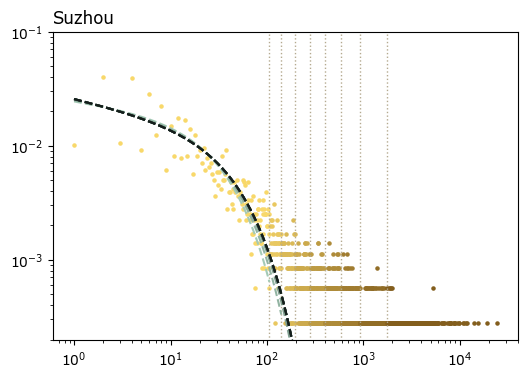

In [18]:

plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

lyg_dot_clr = color_vector((248,216,106), (131,94,29), 9)
lyg_lne_clr = color_vector((164,202,182), (20,30,27), 9)



for v in range(2,10):
    plt.vlines(x=xdata[vline[v]-1], ymin=10e-5,ymax=10e-2, lw=1, ls=":",color="#b5aa90")

#plt.scatter(xdata[:c1], ydata[:c1], s= 5, color=lyg_dot_clr[0])
#plt.scatter(xdata[c1:c2], ydata[c1:c2], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[:c3], ydata[:c3], s= 5, color=lyg_dot_clr[0])
plt.scatter(xdata[c3:c4], ydata[c3:c4], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[c4:c5], ydata[c4:c5], s= 5, color=lyg_dot_clr[2])
plt.scatter(xdata[c5:c6], ydata[c5:c6], s= 5, color=lyg_dot_clr[3])
plt.scatter(xdata[c6:c7], ydata[c6:c7], s= 5, color=lyg_dot_clr[4])
plt.scatter(xdata[c7:c8], ydata[c7:c8], s= 5, color=lyg_dot_clr[5])
plt.scatter(xdata[c8:c9], ydata[c8:c9], s= 5, color=lyg_dot_clr[6])
plt.scatter(xdata[c9:c0], ydata[c9:c0], s= 5, color=lyg_dot_clr[7])
plt.scatter(xdata[c0:], ydata[c0:], s= 5, color=lyg_dot_clr[8])

# plt.plot(xdata[:c1], func2(xdata[:c1], *popt11), ls="--", color=lyg_lne_clr[0], label = '50%')
# plt.plot(xdata[:c2], func2(xdata[:c2], *popt22), ls="--", color=lyg_lne_clr[1], label = '45%')
plt.plot(xdata[:c3], func2(xdata[:c3], *popt33), ls="--", color=lyg_lne_clr[0], label = '40%')
plt.plot(xdata[:c4], func2(xdata[:c4], *popt44), ls="--", color=lyg_lne_clr[1], label = '35%')
plt.plot(xdata[:c5], func2(xdata[:c5], *popt55), ls="--", color=lyg_lne_clr[2], label = '30%')
plt.plot(xdata[:c6], func2(xdata[:c6], *popt66), ls="--", color=lyg_lne_clr[3], label = '25%')
plt.plot(xdata[:c7], func2(xdata[:c7], *popt77), ls="--", color=lyg_lne_clr[4], label = '20%')
plt.plot(xdata[:c8], func2(xdata[:c8], *popt88), ls="--", color=lyg_lne_clr[5], label = '15%')
plt.plot(xdata[:c9], func2(xdata[:c9], *popt99), ls="--", color=lyg_lne_clr[6], label = '10%')
plt.plot(xdata[:c0], func2(xdata[:c0], *popt00), ls="--", color=lyg_lne_clr[7], label = ' 5%')
plt.plot(xdata, func2(xdata, *popt_t), ls="--", color=lyg_lne_clr[8], label = ' 0%')

#plt.vlines(x=c3,ymin=10e-5,ymax=10e-2,lw=2, ls=":",color="#393733")

plt.title('Suzhou',loc='left')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10**-3.7,10e-2))
# plt.legend(loc='upper right')
plt.show()

### community


In [61]:
import igraph as ig

G_ig = ig.Graph(directed=True)
G_ig.add_vertices(list(G.nodes()))
G_ig.add_edges(list(G.edges()))
G_ig.es['weight'] = [d['weight'] for u, v, d in G.edges(data=True)]

isolated_vertex_indices = [v.index for v in G_ig.vs if G_ig.degree(v) == 0]

# 删除这些节点
G_ig.delete_vertices(isolated_vertex_indices)

NameError: name 'G' is not defined

### 其他

In [43]:
s_date = dtm.datetime.strptime('20211001','%Y%m%d')
e_date = dtm.datetime.strptime('20211101','%Y%m%d')
strength = all_strength[(all_strength['date'] >= s_date ) & (all_strength['date'] < e_date)]
strength['date'] = strength['date'].apply(lambda x: dtm.datetime.strftime(x,'%m-%d'))

In [44]:
strength = pd.pivot(strength,index='hex_id',columns='date',values='strength_values')
stre_coor = strength.corr()

In [45]:
import scipy.stats as st
coor_flat = np.zeros(int((len(stre_coor)-1)*len(stre_coor)/2))
m=0
for i in range(len(stre_coor)):
  for j in range(len(stre_coor)):
    if i < j:
      coor_flat[m]=stre_coor.iloc[i,j]
      m=m+1

print(np.mean(coor_flat))
ci = st.t.interval(confidence=0.95, df=len(coor_flat)-1,
              loc=np.mean(coor_flat),
              scale=st.sem(coor_flat))

(ci[1]-ci[0])/2

0.9900433947578223


0.0005496229588993762

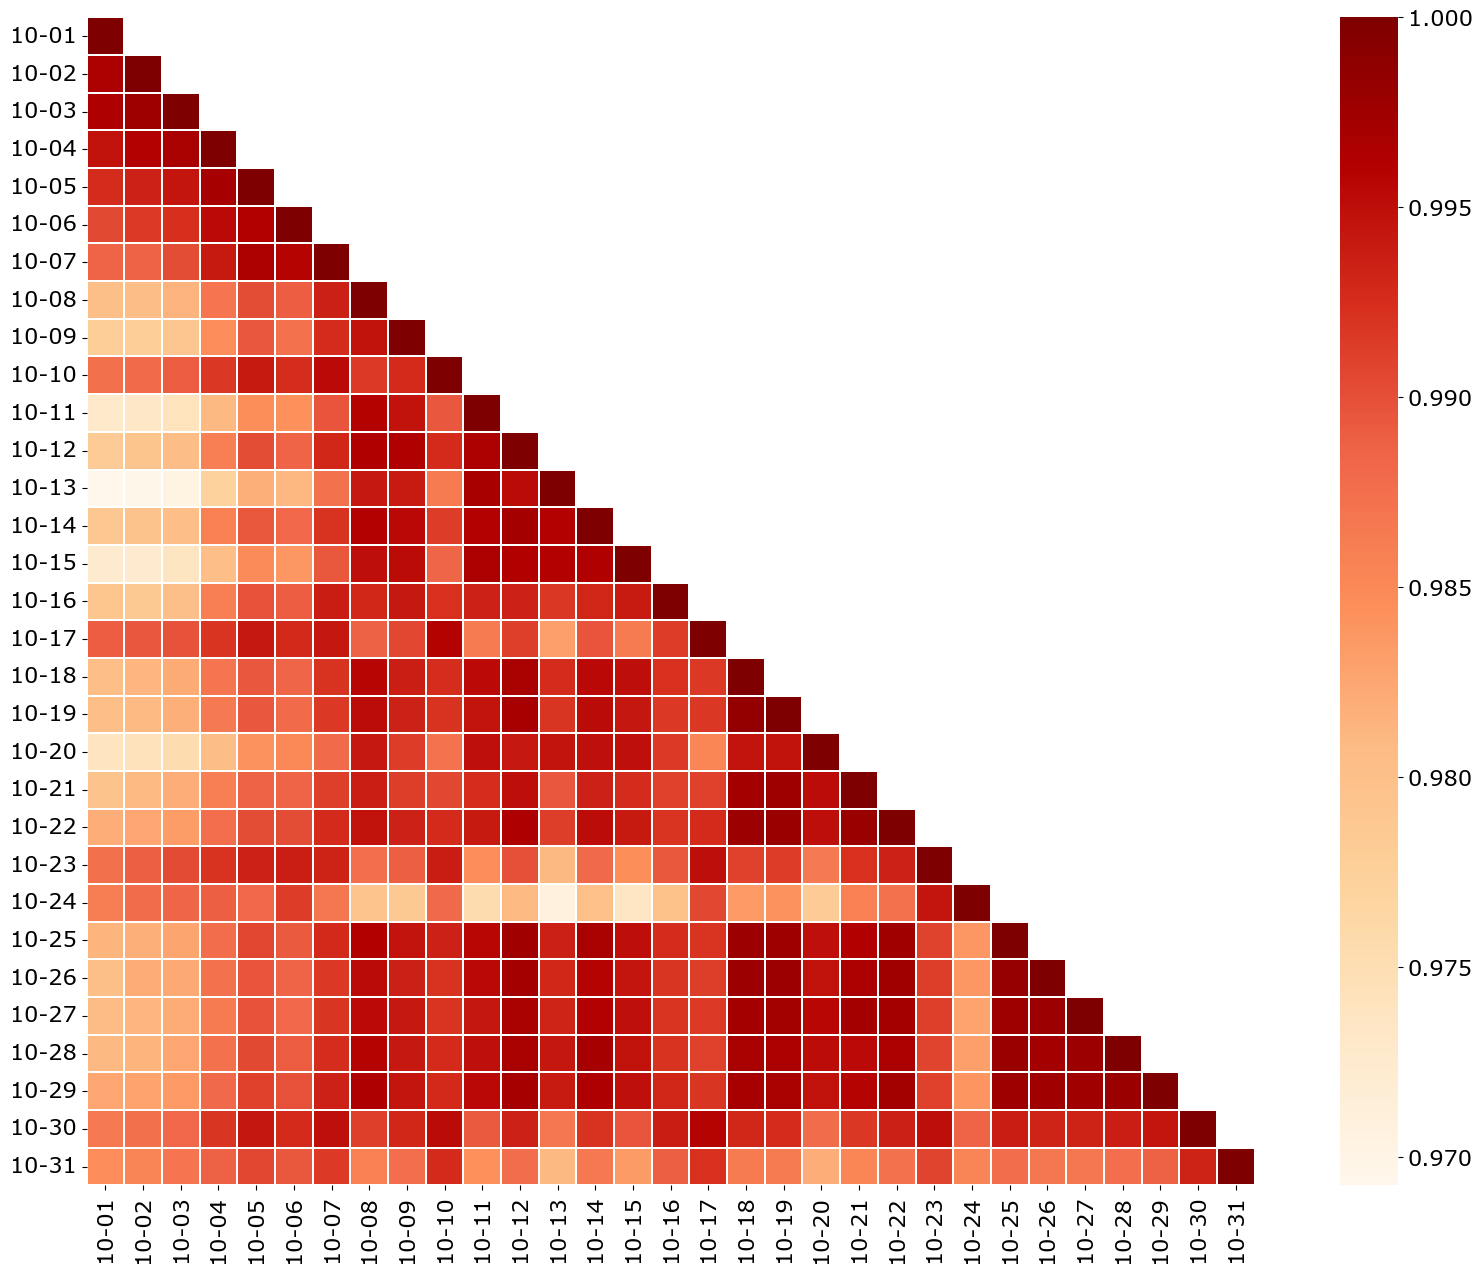

In [46]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
f, ax = plt.subplots(figsize=(20, 16)) 
mask = np.zeros_like(stre_coor)

for i in range(1,len(mask)):

  for j in range(0,i):

    mask[j][i] = True# 掩盖掉上面的三角形

sns.heatmap(stre_coor, annot=False,mask=mask,cmap="OrRd",linewidths=.01,square=True)

plt.subplots_adjust(left=.1, right=0.95, bottom=0.22, top=0.95)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()#显示绘图内容

In [47]:
col = 0

date_stre = strength.iloc[:,col].to_frame().fillna(0)
index_stre = strength.index

In [59]:
all_strength

,hex_id,strength_values,date,Holiday
0,89309818d2bffff,60,2021-10-01,True
1,89309818d2fffff,134,2021-10-01,True
2,89309818d37ffff,67,2021-10-01,True
3,893098032d3ffff,11,2021-10-01,True
4,8930980360fffff,266,2021-10-01,True
...,...,...,...,...
109454,89309e2ed77ffff,2,2021-10-31,True
109455,893098546c7ffff,1,2021-10-31,True
109456,89309857317ffff,2,2021-10-31,True
109457,893098521cbffff,4,2021-10-31,True


In [64]:
from minepy import pstats, cstats
from cmcrameri import cm

sele_strength = all_strength.loc[(all_strength['date'].dt.month==10)]
fluc = sele_strength.groupby(['date']).agg({'strength_values':'describe'})
date_list = pd.date_range(start=fluc.index.min(),end=fluc.index.max(),freq='D')
hexagon = pd.crosstab(
    index=sele_strength['date'],
    columns=all_strength['hex_id'],
    values=all_strength['strength_values'],
    aggfunc='sum').reindex(index=date_list).fillna(0)
hexagon_data = np.array(hexagon)

mic_c, tic_c = cstats(hexagon_data.T,hexagon_data.T,alpha=9,c=15,est="mic_e")
mic = pd.DataFrame(data=mic_c,index=hexagon.columns.values,columns=hexagon.columns.values)


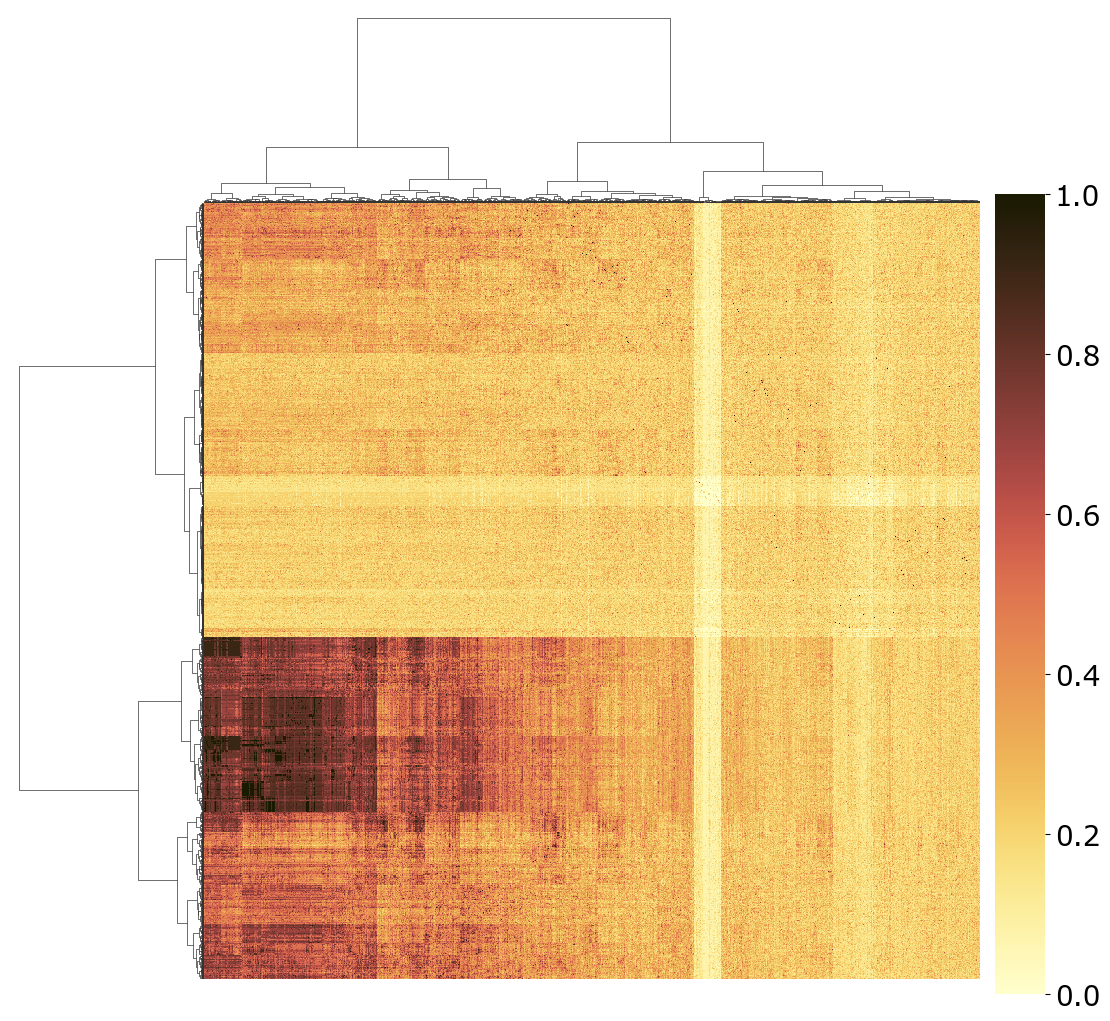

In [80]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.family']=['Verdana']
ax = sns.clustermap(
    data=mic, vmin=0, vmax=1, cmap=cm.lajolla, linecolor='#f1f1f1',
    method = 'ward', metric='euclidean',
    xticklabels=False, yticklabels=False)
ax.cax.set_position([1,0,0.05,0.8])
ax.cax.tick_params(labelsize=20)
plt.show()


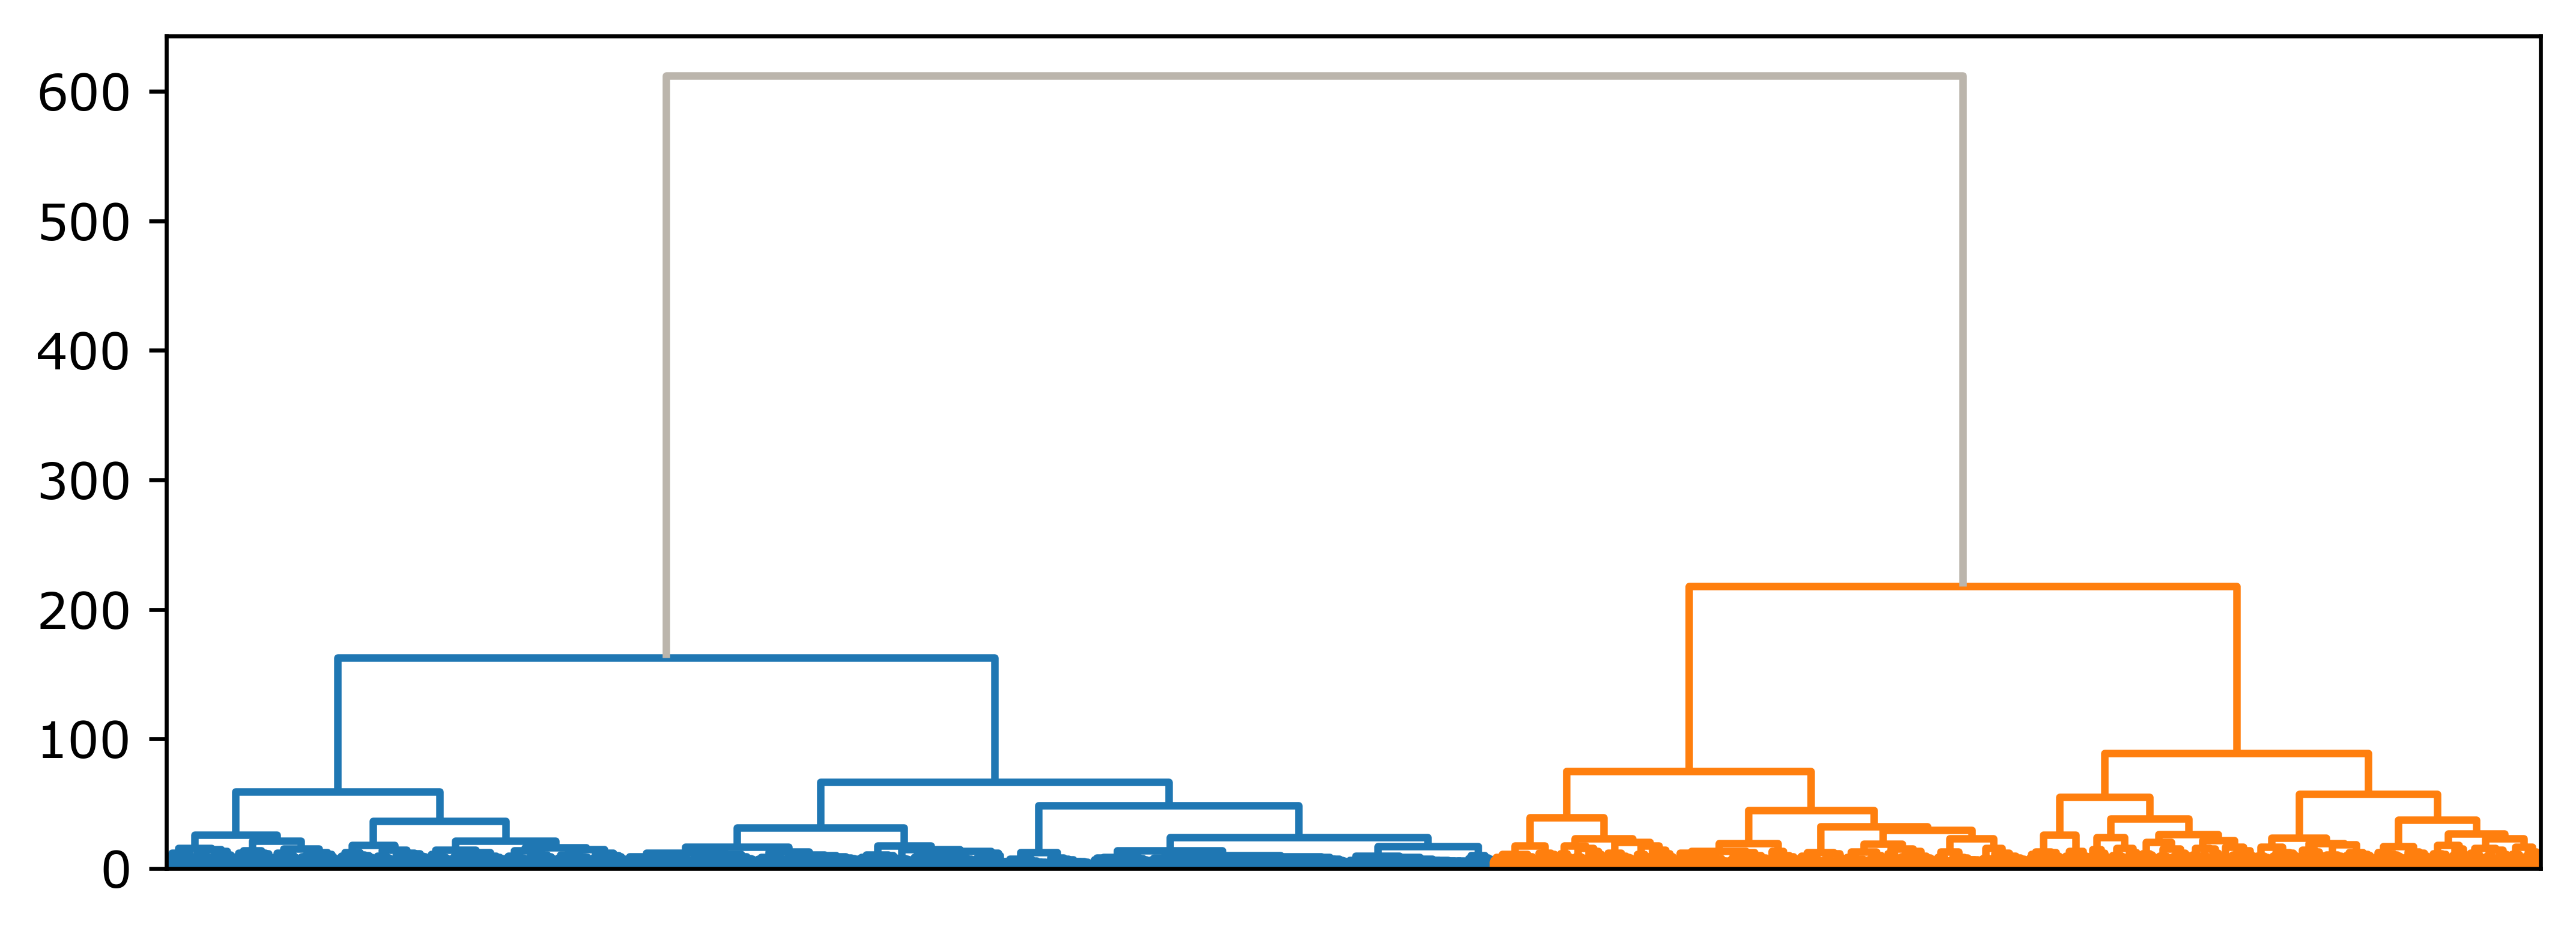

In [85]:
import scipy.cluster.hierarchy as sch
colors_hex = ['#1F77B3', '#FF7F0E', '#2CA02C', '#D62728',
              '#9467BD', '#8C564B', '#E377C2', '#7F7F7F']
plt.figure(dpi=600,figsize=(8.5,3))

plt.rcParams['font.sans-serif'] = ['Verdana']
sch.set_link_color_palette(colors_hex)
thd = 59

#plt.axhline(y=thd,lw=1,ls="--",c="#393733")#添加水平直线
dendrogram = sch.dendrogram(
    sch.linkage(mic, method = 'ward',metric='euclidean'),
    labels=mic.index,above_threshold_color='#bbb5ac')

plt.xticks([])

plt.show()


In [ ]:
from h3 import h3
import folium
import folium.plugins

attr_anno = 'Map tiles by &copy; <a href="https://carto.com/attributions">CARTO</a>, under <a href="http://creativecommons.org/licenses/by/3.0">CC BY 3.0</a>. Data by &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a>, under <a href="https://creativecommons.org/licenses/by-sa/3.0/">CC-BY-SA</a>.'
map_tile = 'https://{s}.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}{r}.png'
cen_loc = [34.6412,119.234865]

In [ ]:
clustering = pd.DataFrame({
    "hexagon_id": dendrogram['ivl'],
    "category": dendrogram['leaves_color_list']
    })
clustering['Polygon'] = clustering['hexagon_id'].apply(lambda x: h3.h3_to_geo_boundary(x))


In [ ]:
city_map = folium.Map(
    location = cen_loc,
    zoom_start = 11,
    max_zoom = 16,
    min_zoom = 8,
    no_touch = True,
    zoom_control = False,
    control_scale = True,
    prefer_canvas = True,
    attr = attr_anno,
    tiles = map_tile,
)

#H3
H3_map = folium.map.FeatureGroup()
for row_index, row_data in clustering.iterrows():
    H3_map.add_child(
        folium.Polygon(
            row_data['Polygon'],
            color = row_data['category'],
            fill_color = row_data['category'],
            fill_opacity = 0.8,
            opacity = 0.2,
            fill = True
        )
    )
    
city_map.add_child(H3_map)

# 添加图例

# 显示地图
map_name = 'SuzhouCLUSTER.html'
map_path = os.path.join(work_path,map_name)
city_map.save(map_path)